In [101]:
import pandas as pd
import numpy as np
from pathlib import Path
import random
import ipaddress

In [102]:
SYNTHETIC_DATA_PATH = Path("dataset/all_low_level_features_merged.csv")

# Output path
OUTPUT_PATH = SYNTHETIC_DATA_PATH.parent / f"{SYNTHETIC_DATA_PATH.stem}_postprocessed.csv"

# QUIC protocol constants
MIN_PACKET_SIZE = 40        # Minimum UDP + QUIC header
MAX_PACKET_SIZE = 1500      # Typical MTU
MIN_INITIAL_SIZE = 1200     # RFC 9000 minimum for Initial packets
MIN_PATH_VALIDATION_SIZE = 1200  # RFC 9000 minimum for path validation

In [103]:
# Load synthetic data
df = pd.read_csv(SYNTHETIC_DATA_PATH)
print(f"Loaded {len(df)} rows from {SYNTHETIC_DATA_PATH}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
df.head(10)

Loaded 261196 rows from dataset/all_low_level_features_merged.csv

Columns: ['frame_number', 'delta_time', 'packet_length', 'packet_direction', 'header_form', 'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt', 'count_retry', 'count_vn', 'count_ack', 'count_padding', 'count_connection_close', 'count_path_challenge', 'count_path_response', 'count_new_connection_id', 'count_retire_cid', 'count_ping', 'count_crypto', 'count_handshake_done', 'http3_stream_count', 'http3_fin_count', 'stream_length', 'stream_type_count', 'capture_id']

Data types:
frame_number                 int64
delta_time                 float64
packet_length                int64
packet_direction             int64
header_form                  int64
count_initial                int64
count_0rtt                   int64
count_handshake              int64
count_1rtt                   int64
count_retry                  int64
count_vn                     int64
count_ack                    int64
count_padding       

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_new_connection_id,count_retire_cid,count_ping,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000000,1242,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
1,2,0.000087,89,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
2,3,0.000554,1242,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,10000
3,4,0.001087,1242,1,1,1,0,1,0,0,...,0,0,0,4,0,0,0,0,0,10000
4,5,0.000021,403,1,1,0,0,1,0,0,...,0,0,0,2,0,0,0,0,0,10000
5,6,0.003077,1392,0,1,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,10000
6,7,0.000251,623,1,0,0,0,0,1,0,...,1,0,0,2,1,2,0,10,1,10000
7,8,0.000153,85,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
8,9,0.000098,1392,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
9,10,0.000032,1242,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000


## Analyze Violations Before Post-Processing

In [104]:
def analyze_low_level_violations(df):
    """Analyze and report constraint violations in the low-level dataset."""
    violations = {}
    
    print("=" * 70)
    print("LOW-LEVEL CONSTRAINT VIOLATION ANALYSIS")
    print("=" * 70)
    
    # 1. NON-NEGATIVITY VIOLATIONS
    print("\n1. NON-NEGATIVITY VIOLATIONS:")
    print("-" * 50)
    
    # Check delta_time
    neg_delta = (df['delta_time'] < 0).sum()
    if neg_delta > 0:
        violations['delta_time_negative'] = neg_delta
        print(f"  delta_time < 0: {neg_delta} rows ({neg_delta/len(df)*100:.2f}%)")
    
    # Check packet_length
    neg_len = (df['packet_length'] <= 0).sum()
    if neg_len > 0:
        violations['packet_length_invalid'] = neg_len
        print(f"  packet_length <= 0: {neg_len} rows ({neg_len/len(df)*100:.2f}%)")
    
    # Check all count columns
    count_cols = [c for c in df.columns if c.startswith('count_')]
    for col in count_cols:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            violations[f"{col}_negative"] = neg_count
            print(f"  {col} < 0: {neg_count} rows ({neg_count/len(df)*100:.2f}%)")
    
    # Check stream_length
    if 'stream_length' in df.columns:
        neg_stream = (df['stream_length'] < 0).sum()
        if neg_stream > 0:
            violations['stream_length_negative'] = neg_stream
            print(f"  stream_length < 0: {neg_stream} rows ({neg_stream/len(df)*100:.2f}%)")
    
    if not any('negative' in k or 'invalid' in k for k in violations):
        print("  No non-negativity violations found.")
    
    # 2. PACKET SIZE VIOLATIONS
    print("\n2. PACKET SIZE VIOLATIONS:")
    print("-" * 50)
    
    # Too small packets
    too_small = (df['packet_length'] < MIN_PACKET_SIZE).sum()
    if too_small > 0:
        violations['packet_too_small'] = too_small
        print(f"  packet_length < {MIN_PACKET_SIZE}: {too_small} rows ({too_small/len(df)*100:.2f}%)")
    
    # Too large packets
    too_large = (df['packet_length'] > MAX_PACKET_SIZE).sum()
    if too_large > 0:
        violations['packet_too_large'] = too_large
        print(f"  packet_length > {MAX_PACKET_SIZE}: {too_large} rows ({too_large/len(df)*100:.2f}%)")
    
    # Initial packets too small (RFC 9000 requires >= 1200)
    if 'count_initial' in df.columns:
        initial_mask = df['count_initial'] > 0
        initial_too_small = ((df['packet_length'] < MIN_INITIAL_SIZE) & initial_mask).sum()
        if initial_too_small > 0:
            violations['initial_packet_too_small'] = initial_too_small
            print(f"  Initial packets < {MIN_INITIAL_SIZE}: {initial_too_small} rows")
    
    # Path validation packets too small
    if 'count_path_challenge' in df.columns:
        pc_mask = df['count_path_challenge'] > 0
        pc_too_small = ((df['packet_length'] < MIN_PATH_VALIDATION_SIZE) & pc_mask).sum()
        if pc_too_small > 0:
            violations['path_challenge_too_small'] = pc_too_small
            print(f"  PATH_CHALLENGE packets < {MIN_PATH_VALIDATION_SIZE}: {pc_too_small} rows")
    
    if not any('packet' in k for k in violations):
        print("  No packet size violations found.")
    
    # 3. BINARY/CATEGORICAL VIOLATIONS
    print("\n3. BINARY/CATEGORICAL FIELD VIOLATIONS:")
    print("-" * 50)
    
    # header_form should be 0 or 1
    if 'header_form' in df.columns:
        invalid_header = (~df['header_form'].isin([0, 1])).sum()
        if invalid_header > 0:
            violations['header_form_invalid'] = invalid_header
            print(f"  header_form not in [0,1]: {invalid_header} rows")
    
    # packet_direction should be 0 or 1
    if 'packet_direction' in df.columns:
        invalid_dir = (~df['packet_direction'].isin([0, 1])).sum()
        if invalid_dir > 0:
            violations['packet_direction_invalid'] = invalid_dir
            print(f"  packet_direction not in [0,1]: {invalid_dir} rows")
    
    if not any('invalid' in k for k in violations if 'header' in k or 'direction' in k):
        print("  No binary/categorical violations found.")
    
    # 4. LOGICAL CONSISTENCY VIOLATIONS
    print("\n4. LOGICAL CONSISTENCY VIOLATIONS:")
    print("-" * 50)
    
    # Initial packets should have long header (header_form=1)
    if 'count_initial' in df.columns and 'header_form' in df.columns:
        initial_short_header = ((df['count_initial'] > 0) & (df['header_form'] == 0)).sum()
        if initial_short_header > 0:
            violations['initial_with_short_header'] = initial_short_header
            print(f"  Initial packets with short header: {initial_short_header} rows")
    
    # Handshake packets should have long header (header_form=1)
    if 'count_handshake' in df.columns and 'header_form' in df.columns:
        hs_short_header = ((df['count_handshake'] > 0) & (df['header_form'] == 0)).sum()
        if hs_short_header > 0:
            violations['handshake_with_short_header'] = hs_short_header
            print(f"  Handshake packets with short header: {hs_short_header} rows")
    
    # stream_length should be 0 if no streams
    if 'stream_length' in df.columns and 'http3_stream_count' in df.columns:
        stream_without_count = ((df['stream_length'] > 0) & (df['http3_stream_count'] == 0)).sum()
        if stream_without_count > 0:
            violations['stream_length_without_stream'] = stream_without_count
            print(f"  stream_length > 0 but http3_stream_count = 0: {stream_without_count} rows")
    
    # stream_length should be <= packet_length - overhead
    if 'stream_length' in df.columns:
        overhead = 50  # Approximate header overhead
        stream_too_large = (df['stream_length'] > df['packet_length'] - overhead).sum()
        if stream_too_large > 0:
            violations['stream_length_exceeds_packet'] = stream_too_large
            print(f"  stream_length > packet_length - {overhead}: {stream_too_large} rows")
    
    if not any(k for k in violations if 'header' in k or 'stream' in k):
        print("  No logical consistency violations found.")
    
    # 5. INTEGER TYPE VIOLATIONS
    print("\n5. INTEGER TYPE VIOLATIONS (non-integer values):")
    print("-" * 50)
    
    int_cols = ['frame_number', 'packet_length', 'packet_direction', 'header_form'] + count_cols
    if 'stream_length' in df.columns:
        int_cols.append('stream_length')
    if 'stream_type_count' in df.columns:
        int_cols.append('stream_type_count')
    if 'http3_stream_count' in df.columns:
        int_cols.append('http3_stream_count')
    if 'http3_fin_count' in df.columns:
        int_cols.append('http3_fin_count')
    
    non_int_found = False
    for col in int_cols:
        if col in df.columns:
            # Check if values are non-integer floats
            if df[col].dtype == 'float64':
                non_int = (df[col] != df[col].round()).sum()
                if non_int > 0:
                    violations[f"{col}_non_integer"] = non_int
                    print(f"  {col}: {non_int} non-integer values")
                    non_int_found = True
    
    if not non_int_found:
        print("  No non-integer violations found.")
    
    # SUMMARY
    print("\n" + "=" * 70)
    print(f"TOTAL TYPES OF VIOLATIONS: {len(violations)}")
    print("=" * 70)
    
    return violations

violations_before = analyze_low_level_violations(df)

LOW-LEVEL CONSTRAINT VIOLATION ANALYSIS

1. NON-NEGATIVITY VIOLATIONS:
--------------------------------------------------
  delta_time < 0: 127 rows (0.05%)

2. PACKET SIZE VIOLATIONS:
--------------------------------------------------
  Initial packets < 1200: 3660 rows
  PATH_CHALLENGE packets < 1200: 2750 rows

3. BINARY/CATEGORICAL FIELD VIOLATIONS:
--------------------------------------------------
  No binary/categorical violations found.

4. LOGICAL CONSISTENCY VIOLATIONS:
--------------------------------------------------
  No logical consistency violations found.

5. INTEGER TYPE VIOLATIONS (non-integer values):
--------------------------------------------------
  No non-integer violations found.

TOTAL TYPES OF VIOLATIONS: 3


## Post-Processing Functions

In [105]:
def fix_non_negativity(df):
    """
    Fix non-negativity constraints.
    - delta_time >= 0
    - All count fields >= 0
    - stream_length >= 0
    """
    df = df.copy()
    print("\nFixing non-negativity constraints...")
    
    # Fix delta_time
    if 'delta_time' in df.columns:
        neg_count = (df['delta_time'] < 0).sum()
        if neg_count > 0:
            df['delta_time'] = df['delta_time'].clip(lower=0)
            print(f"  Clipped {neg_count} negative delta_time values to 0")
    
    # Fix all count columns
    count_cols = [c for c in df.columns if c.startswith('count_')]
    for col in count_cols:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            df[col] = df[col].clip(lower=0)
            print(f"  Clipped {neg_count} negative {col} values to 0")
    
    # Fix stream_length
    if 'stream_length' in df.columns:
        neg_count = (df['stream_length'] < 0).sum()
        if neg_count > 0:
            df['stream_length'] = df['stream_length'].clip(lower=0)
            print(f"  Clipped {neg_count} negative stream_length values to 0")
    
    return df

In [106]:
def fix_packet_sizes(df, min_size=MIN_PACKET_SIZE, max_size=MAX_PACKET_SIZE,
                     min_initial=MIN_INITIAL_SIZE, min_path_val=MIN_PATH_VALIDATION_SIZE):
    """
    Fix packet size constraints.
    - Ensure minimum packet size
    - Ensure maximum packet size (MTU)
    - Ensure Initial packets >= 1200 bytes
    - Ensure PATH_CHALLENGE/RESPONSE packets >= 1200 bytes
    """
    df = df.copy()
    print("\nFixing packet size constraints...")
    
    # Fix minimum packet size
    too_small = (df['packet_length'] < min_size).sum()
    if too_small > 0:
        df.loc[df['packet_length'] < min_size, 'packet_length'] = min_size
        print(f"  Increased {too_small} packets to minimum size {min_size}")
    
    # Fix maximum packet size
    too_large = (df['packet_length'] > max_size).sum()
    if too_large > 0:
        df.loc[df['packet_length'] > max_size, 'packet_length'] = max_size
        print(f"  Capped {too_large} packets to maximum size {max_size}")
    
    # Fix Initial packets (must be >= 1200 bytes per RFC 9000)
    if 'count_initial' in df.columns:
        initial_mask = df['count_initial'] > 0
        initial_too_small = (df['packet_length'] < min_initial) & initial_mask
        count = initial_too_small.sum()
        if count > 0:
            df.loc[initial_too_small, 'packet_length'] = min_initial
            print(f"  Increased {count} Initial packets to {min_initial} bytes")
    
    # Fix PATH_CHALLENGE packets
    if 'count_path_challenge' in df.columns:
        pc_mask = df['count_path_challenge'] > 0
        pc_too_small = (df['packet_length'] < min_path_val) & pc_mask
        count = pc_too_small.sum()
        if count > 0:
            df.loc[pc_too_small, 'packet_length'] = min_path_val
            print(f"  Increased {count} PATH_CHALLENGE packets to {min_path_val} bytes")
    
    # Fix PATH_RESPONSE packets (should also be padded)
    if 'count_path_response' in df.columns:
        pr_mask = df['count_path_response'] > 0
        pr_too_small = (df['packet_length'] < min_path_val) & pr_mask
        count = pr_too_small.sum()
        if count > 0:
            df.loc[pr_too_small, 'packet_length'] = min_path_val
            print(f"  Increased {count} PATH_RESPONSE packets to {min_path_val} bytes")
    
    return df

In [107]:
def fix_binary_fields(df):
    """
    Fix binary/categorical fields.
    - header_form: round and clip to [0, 1]
    - packet_direction: round and clip to [0, 1]
    """
    df = df.copy()
    print("\nFixing binary/categorical fields...")
    
    # Fix header_form
    if 'header_form' in df.columns:
        invalid = (~df['header_form'].isin([0, 1])).sum()
        if invalid > 0:
            df['header_form'] = df['header_form'].round().clip(0, 1).astype(int)
            print(f"  Fixed {invalid} invalid header_form values")
    
    # Fix packet_direction
    if 'packet_direction' in df.columns:
        invalid = (~df['packet_direction'].isin([0, 1])).sum()
        if invalid > 0:
            df['packet_direction'] = df['packet_direction'].round().clip(0, 1).astype(int)
            print(f"  Fixed {invalid} invalid packet_direction values")
    
    return df

In [108]:
def fix_logical_constraints(df):
    """
    Fix logical consistency constraints.
    - Initial/Handshake packets should have long header
    - stream_length consistency with http3_stream_count
    - stream_length should not exceed packet payload size
    """
    df = df.copy()
    print("\nFixing logical consistency constraints...")
    
    # Fix: Initial packets should have long header (header_form=1)
    if 'count_initial' in df.columns and 'header_form' in df.columns:
        mask = (df['count_initial'] > 0) & (df['header_form'] == 0)
        count = mask.sum()
        if count > 0:
            df.loc[mask, 'header_form'] = 1
            print(f"  Set header_form=1 for {count} Initial packets")
    
    # Fix: Handshake packets should have long header (header_form=1)
    if 'count_handshake' in df.columns and 'header_form' in df.columns:
        mask = (df['count_handshake'] > 0) & (df['header_form'] == 0)
        count = mask.sum()
        if count > 0:
            df.loc[mask, 'header_form'] = 1
            print(f"  Set header_form=1 for {count} Handshake packets")
    
    # Fix: If http3_stream_count is 0, stream_length should be 0
    if 'stream_length' in df.columns and 'http3_stream_count' in df.columns:
        mask = (df['http3_stream_count'] == 0) & (df['stream_length'] > 0)
        count = mask.sum()
        if count > 0:
            df.loc[mask, 'stream_length'] = 0
            print(f"  Set stream_length=0 for {count} packets with no streams")
    
    # Fix: stream_length should not exceed packet payload size
    if 'stream_length' in df.columns:
        overhead = 50  # Approximate QUIC + UDP + IP header overhead
        max_payload = df['packet_length'] - overhead
        mask = df['stream_length'] > max_payload
        count = mask.sum()
        if count > 0:
            df.loc[mask, 'stream_length'] = max_payload.loc[mask].clip(lower=0)
            print(f"  Reduced stream_length for {count} packets to fit within packet")
    
    # Fix: http3_fin_count should not exceed http3_stream_count
    if 'http3_fin_count' in df.columns and 'http3_stream_count' in df.columns:
        mask = df['http3_fin_count'] > df['http3_stream_count']
        count = mask.sum()
        if count > 0:
            df.loc[mask, 'http3_fin_count'] = df.loc[mask, 'http3_stream_count']
            print(f"  Capped http3_fin_count for {count} packets")
    
    return df

In [109]:
def fix_integer_columns(df):
    """
    Round and convert columns that should be integers.
    """
    df = df.copy()
    print("\nRounding integer columns...")
    
    # Columns that should be integers
    int_cols = [
        'frame_number', 'packet_length', 'packet_direction', 'header_form',
        'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt',
        'count_retry', 'count_vn', 'count_ack', 'count_padding',
        'count_connection_close', 'count_path_challenge', 'count_path_response',
        'count_new_connection_id', 'count_retire_cid', 'count_ping',
        'count_crypto', 'count_handshake_done',
        'http3_stream_count', 'http3_fin_count', 'stream_length', 'stream_type_count'
    ]
    
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].round().astype(int)
    
    print(f"  Rounded {len([c for c in int_cols if c in df.columns])} columns to integers")
    
    return df

In [110]:
def fix_first_packet_delta(df):
    """
    Ensure first packet of each capture has delta_time = 0.
    """
    df = df.copy()
    print("\nFixing first packet delta times...")
    
    # Check if capture_id column exists for grouping
    if 'capture_id' in df.columns:
        # Get first packet of each capture
        first_indices = df.groupby('capture_id').first().index
        # Find actual row indices
        first_rows = df.groupby('capture_id').head(1).index
        
        violations = (df.loc[first_rows, 'delta_time'] != 0).sum()
        if violations > 0:
            df.loc[first_rows, 'delta_time'] = 0
            print(f"  Set delta_time=0 for {violations} first packets")
        else:
            print("  All first packets already have delta_time=0")
    else:
        # Assume frame_number=1 is first packet
        if 'frame_number' in df.columns:
            first_mask = df['frame_number'] == 1
            violations = (df.loc[first_mask, 'delta_time'] != 0).sum()
            if violations > 0:
                df.loc[first_mask, 'delta_time'] = 0
                print(f"  Set delta_time=0 for {violations} first packets (frame_number=1)")
    
    return df

In [93]:
"""
- Geneartes realistic client-server endpoints 
- Detects QUIC migration by checking PC/PR frames and updates the client IP and port accordingly
"""
def get_random_public_ip(rng):
    # Generating a random public IPv4 address
    # Filtering out private and multicast ranges to ensure the IP looks like real internet traffic
    while True:
        ip = ipaddress.IPv4Address(rng.getrandbits(32))
        if ip.is_global and not ip.is_multicast:
            return str(ip)

def get_random_public_ip_not_equal(rng, excluded_ips):
    while True:
        ip = get_random_public_ip(rng)
        if ip not in excluded_ips:
            return ip

def get_random_port(rng, excluded_ports):
    return max(excluded_ports) + 1
        
def add_low_level_migration_endpoints(df, seed=42, server_port=443):
    rng = random.Random(seed)
    df = df.copy()

    for col in ["source_ip", "source_port", "destination_ip", "destination_port"]:
        df[col] = None

    for capture_id, group in df.groupby("capture_id", sort=False):
        server_ip = get_random_public_ip(rng)

        # Initial client endpoint
        initial_client_ip = get_random_public_ip_not_equal(rng, server_ip)
        initial_client_port = rng.randint(49152, 65535)

        # Detecting migration by path validation frames
        has_migration = (
            (group.get("count_path_challenge", 0) > 0).any()
            or (group.get("count_path_response", 0) > 0).any()
        )

        # No migration
        client_ip_after_migration = initial_client_ip
        client_port_after_migration = initial_client_port

        # If migration: IP and port change
        if has_migration:
            client_ip_after_migration = get_random_public_ip_not_equal(
                rng, [server_ip, initial_client_ip]
            )

            client_port_after_migration = get_random_port(
                rng, [initial_client_port]
            )

        # Switching point: when PATH_CHALLENGE/RESPONSE first appears
        switch_idx = None
        if has_migration:
            mask = (group["count_path_challenge"] > 0) | (group["count_path_response"] > 0)
            switch_idx = group.index[mask][0] if mask.any() else group.index[0]

        for idx in group.index:
            after_migration = (switch_idx is not None) and (idx >= switch_idx)
            current_client_ip = client_ip_after_migration if after_migration else initial_client_ip
            current_client_port = client_port_after_migration if after_migration else initial_client_port

            if int(df.at[idx, "packet_direction"]) == 0:
                df.at[idx, "source_ip"] = current_client_ip
                df.at[idx, "source_port"] = int(current_client_port)
                df.at[idx, "destination_ip"] = server_ip
                df.at[idx, "destination_port"] = int(server_port)
            else:
                df.at[idx, "source_ip"] = server_ip
                df.at[idx, "source_port"] = int(server_port)
                df.at[idx, "destination_ip"] = current_client_ip
                df.at[idx, "destination_port"] = int(current_client_port)

    return df

## Apply Post-Processing

In [94]:
def apply_low_level_post_processing(df):
    """
    Apply all post-processing rules to the low-level synthetic data.
    
    Returns:
    --------
    pd.DataFrame
        Post-processed data
    """
    print("\n" + "="*70)
    print("APPLYING LOW-LEVEL POST-PROCESSING RULES")
    print("="*70)
    
    # Step 1: Fix non-negativity
    print("\n[Step 1/6] Fixing non-negativity constraints...")
    df = fix_non_negativity(df)
    
    # Step 2: Fix binary fields
    print("\n[Step 2/6] Fixing binary/categorical fields...")
    df = fix_binary_fields(df)
    
    # Step 3: Fix logical constraints (before packet sizes, as it may affect header_form)
    print("\n[Step 3/6] Fixing logical consistency...")
    df = fix_logical_constraints(df)
    
    # Step 4: Fix packet sizes (after logical fixes)
    print("\n[Step 4/6] Fixing packet sizes...")
    df = fix_packet_sizes(df)
    
    # Step 5: Fix first packet delta times
    print("\n[Step 5/6] Fixing first packet delta times...")
    df = fix_first_packet_delta(df)
    
    # Step 6: Round integer columns (last step to ensure clean output)
    print("\n[Step 6/6] Rounding integer columns...")
    df = fix_integer_columns(df)

    # Step 7: Add migration endpoints
    print("\n[Step 7/7] Generating IP/Port migration endpoints...")
    df = add_low_level_migration_endpoints(df, seed=42, server_port=443)
    
    print("\n" + "="*70)
    print("POST-PROCESSING COMPLETE")
    print("="*70)
    
    return df

In [95]:
# Apply post-processing
df_processed = apply_low_level_post_processing(df)


APPLYING LOW-LEVEL POST-PROCESSING RULES

[Step 1/6] Fixing non-negativity constraints...

Fixing non-negativity constraints...
  Clipped 127 negative delta_time values to 0

[Step 2/6] Fixing binary/categorical fields...

Fixing binary/categorical fields...

[Step 3/6] Fixing logical consistency...

Fixing logical consistency constraints...

[Step 4/6] Fixing packet sizes...

Fixing packet size constraints...
  Increased 3660 Initial packets to 1200 bytes
  Increased 2750 PATH_CHALLENGE packets to 1200 bytes
  Increased 11894 PATH_RESPONSE packets to 1200 bytes

[Step 5/6] Fixing first packet delta times...

Fixing first packet delta times...
  All first packets already have delta_time=0

[Step 6/6] Rounding integer columns...

Rounding integer columns...
  Rounded 24 columns to integers

[Step 7/7] Generating IP/Port migration endpoints...

POST-PROCESSING COMPLETE


## Verify Results

In [96]:
print("\nVIOLATIONS AFTER POST-PROCESSING:")
violations_after = analyze_low_level_violations(df_processed)


VIOLATIONS AFTER POST-PROCESSING:
LOW-LEVEL CONSTRAINT VIOLATION ANALYSIS

1. NON-NEGATIVITY VIOLATIONS:
--------------------------------------------------
  No non-negativity violations found.

2. PACKET SIZE VIOLATIONS:
--------------------------------------------------
  No packet size violations found.

3. BINARY/CATEGORICAL FIELD VIOLATIONS:
--------------------------------------------------
  No binary/categorical violations found.

4. LOGICAL CONSISTENCY VIOLATIONS:
--------------------------------------------------
  No logical consistency violations found.

5. INTEGER TYPE VIOLATIONS (non-integer values):
--------------------------------------------------
  No non-integer violations found.

TOTAL TYPES OF VIOLATIONS: 0


In [97]:
# Compare statistics before and after
print("\nComparison of key columns:")
print("=" * 70)

key_cols = ['delta_time', 'packet_length', 'stream_length']
existing_cols = [c for c in key_cols if c in df.columns]

comparison = pd.DataFrame({
    'Column': existing_cols,
    'Before_Mean': [df[c].mean() for c in existing_cols],
    'After_Mean': [df_processed[c].mean() for c in existing_cols],
    'Before_Min': [df[c].min() for c in existing_cols],
    'After_Min': [df_processed[c].min() for c in existing_cols],
    'Before_Max': [df[c].max() for c in existing_cols],
    'After_Max': [df_processed[c].max() for c in existing_cols],
})
print(comparison.to_string(index=False))


Comparison of key columns:
       Column  Before_Mean  After_Mean  Before_Min  After_Min  Before_Max   After_Max
   delta_time     0.007716    0.007722   -1.501113        0.0    1.074398    1.074398
packet_length   488.502431  566.370392   58.000000       58.0 1398.000000 1398.000000
stream_length    26.666408   26.666408    0.000000        0.0  878.000000  878.000000


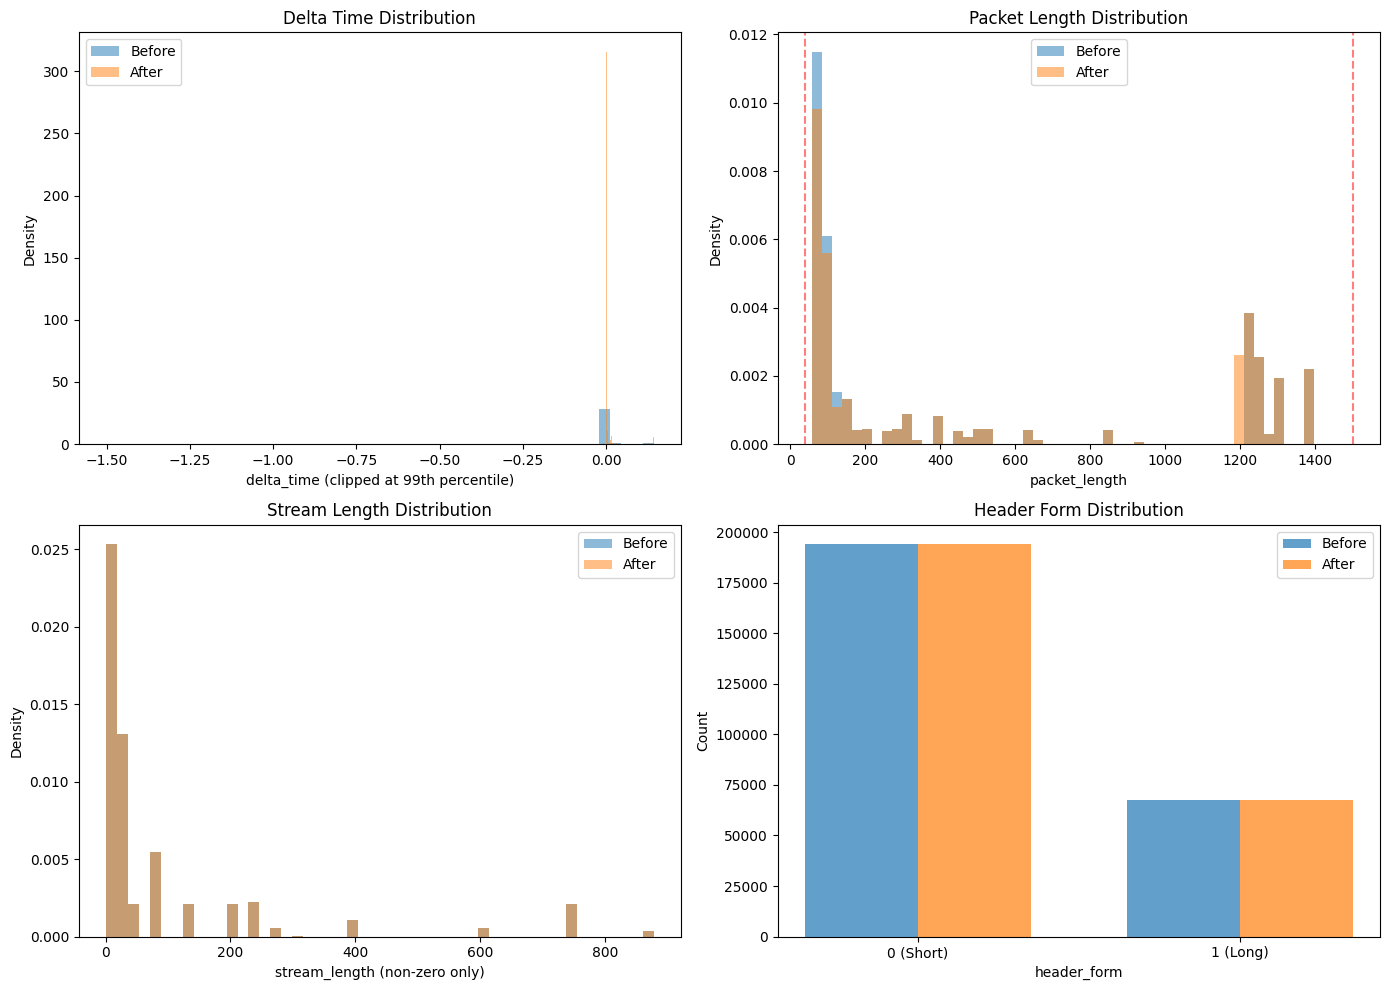

In [98]:
# Visualize the effect of post-processing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delta time distribution
ax = axes[0, 0]
ax.hist(df['delta_time'].clip(upper=df['delta_time'].quantile(0.99)), bins=50, alpha=0.5, label='Before', density=True)
ax.hist(df_processed['delta_time'].clip(upper=df_processed['delta_time'].quantile(0.99)), bins=50, alpha=0.5, label='After', density=True)
ax.set_xlabel('delta_time (clipped at 99th percentile)')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('Delta Time Distribution')

# Packet length distribution
ax = axes[0, 1]
ax.hist(df['packet_length'], bins=50, alpha=0.5, label='Before', density=True)
ax.hist(df_processed['packet_length'], bins=50, alpha=0.5, label='After', density=True)
ax.set_xlabel('packet_length')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('Packet Length Distribution')
ax.axvline(x=MIN_PACKET_SIZE, color='r', linestyle='--', alpha=0.5, label=f'Min ({MIN_PACKET_SIZE})')
ax.axvline(x=MAX_PACKET_SIZE, color='r', linestyle='--', alpha=0.5, label=f'Max ({MAX_PACKET_SIZE})')

# Stream length distribution
if 'stream_length' in df.columns:
    ax = axes[1, 0]
    mask_before = df['stream_length'] > 0
    mask_after = df_processed['stream_length'] > 0
    if mask_before.sum() > 0:
        ax.hist(df.loc[mask_before, 'stream_length'], bins=50, alpha=0.5, label='Before', density=True)
    if mask_after.sum() > 0:
        ax.hist(df_processed.loc[mask_after, 'stream_length'], bins=50, alpha=0.5, label='After', density=True)
    ax.set_xlabel('stream_length (non-zero only)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_title('Stream Length Distribution')

# Header form distribution
ax = axes[1, 1]
if 'header_form' in df.columns:
    before_counts = df['header_form'].value_counts().sort_index()
    after_counts = df_processed['header_form'].value_counts().sort_index()
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [before_counts.get(0, 0), before_counts.get(1, 0)], width, label='Before', alpha=0.7)
    ax.bar(x + width/2, [after_counts.get(0, 0), after_counts.get(1, 0)], width, label='After', alpha=0.7)
    ax.set_xlabel('header_form')
    ax.set_ylabel('Count')
    ax.set_xticks(x)
    ax.set_xticklabels(['0 (Short)', '1 (Long)'])
    ax.legend()
    ax.set_title('Header Form Distribution')

plt.tight_layout()
plt.show()

## Save Post-Processed Data

In [99]:
# Save the post-processed data
df_processed.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved post-processed data to: {OUTPUT_PATH}")
print(f"Total rows: {len(df_processed)}")


Saved post-processed data to: dataset/all_low_level_features_merged_postprocessed.csv
Total rows: 261196


In [100]:
# Quick sanity check on saved data
df_check = pd.read_csv(OUTPUT_PATH)
print(f"\nVerification - loaded {len(df_check)} rows from saved file")
df_check.head(10)


Verification - loaded 261196 rows from saved file


,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id,source_ip,source_port,destination_ip,destination_port
0,1,0.000000,1242,0,0,0,0,0,1,0,...,0,0,0,0,0,10000,28.128.49.127,49971,163.177.121.157,443
1,2,0.000087,89,1,0,0,0,0,1,0,...,0,0,0,0,0,10000,163.177.121.157,443,28.128.49.127,49971
2,3,0.000554,1242,0,1,1,0,0,0,0,...,0,0,0,0,0,10000,28.128.49.127,49971,163.177.121.157,443
3,4,0.001087,1242,1,1,1,0,1,0,0,...,0,0,0,0,0,10000,163.177.121.157,443,28.128.49.127,49971
4,5,0.000021,403,1,1,0,0,1,0,0,...,0,0,0,0,0,10000,163.177.121.157,443,28.128.49.127,49971
5,6,0.003077,1392,0,1,1,0,1,1,0,...,0,0,0,0,0,10000,28.128.49.127,49971,163.177.121.157,443
6,7,0.000251,623,1,0,0,0,0,1,0,...,1,2,0,10,1,10000,163.177.121.157,443,28.128.49.127,49971
7,8,0.000153,85,0,0,0,0,0,1,0,...,0,0,0,0,0,10000,28.128.49.127,49971,163.177.121.157,443
8,9,0.000098,1392,0,0,0,0,0,1,0,...,0,0,0,0,0,10000,189.214.64.251,49972,163.177.121.157,443
9,10,0.000032,1242,1,0,0,0,0,1,0,...,0,0,0,0,0,10000,163.177.121.157,443,189.214.64.251,49972
